In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, f1_score
from sklearn.preprocessing import LabelEncoder
import time

# 1. Load the Data
print("Waking up the dataset...")
df = pd.read_csv('/content/flair_data.csv')


df = df[['question', 'link_flair_text']].dropna()
df.columns = ['text', 'flair']

# Filter to the Top 5 flairs to avoid the long tail of weird, niche questions
top_flairs = df['flair'].value_counts().nlargest(5).index
df = df[df['flair'].isin(top_flairs)]

# 2. Exploratory Data Analysis (EDA)
print("\n--- EXPLORATORY DATA ANALYSIS ---")
print(f"Total Usable Documents: {df.shape[0]}")
print("\nClass Distribution:")
print(df['flair'].value_counts())

# Let's see how much people are rambling
df['word_count'] = df['text'].apply(lambda x: len(str(x).split()))
print("\nAverage Word Count by Flair:")
print(df.groupby('flair')['word_count'].mean().round(2))

Waking up the dataset...


/tmp/ipykernel_8428/3968050687.py:14: DtypeWarning: Columns (8,18) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('/content/flair_data.csv')



--- EXPLORATORY DATA ANALYSIS ---
Total Usable Documents: 402794

Class Distribution:
flair
Physics       121773
Biology       103713
Human Body     95104
Chemistry      43433
Astronomy      38771
Name: count, dtype: int64

Average Word Count by Flair:
flair
Astronomy     16.26
Biology       14.45
Chemistry     13.44
Human Body    14.78
Physics       15.58
Name: word_count, dtype: float64


In [ ]:
df_sampled = df.sample(20000, random_state=42)

# 3. Encoding the Target Variable
# XGBoost requires target classes to be numeric (0, 1, 2, 3, 4)
encoder = LabelEncoder()
y = encoder.fit_transform(df_sampled['flair'])
X = df_sampled['text']

# Train-Test Split (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 4. TF-IDF Vectorization
# Ignoring generic stop words, and terms that are too common (>80%) or too rare (<5 mentions)
print("Vectorizing the text (turning human anxiety into math)...")
tfidf = TfidfVectorizer(stop_words='english', max_df=0.8, min_df=5)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print(f"Extracted {X_train_tfidf.shape[1]} unique text features.")

Vectorizing the text (turning human anxiety into math)...
Extracted 3666 unique text features.


In [5]:
print("--- STARTING THE MODEL THUNDERDOME ---\n")

# --- MODEL 1: Logistic Regression ---
print("Training Logistic Regression (The Baseline)...")
start_time = time.time()

log_param_grid = {'C': [0.1, 1, 10], 'class_weight': ['balanced']}
log_grid = GridSearchCV(LogisticRegression(max_iter=1000), log_param_grid, cv=3, scoring='f1_macro', n_jobs=-1)
log_grid.fit(X_train_tfidf, y_train)

log_best = log_grid.best_estimator_
log_preds = log_best.predict(X_test_tfidf)

print(f"Logistic Regression done in {round(time.time() - start_time, 2)} seconds.")
print(f"Best Params: {log_grid.best_params_}\n")

# --- MODEL 2: XGBoost ---
print("Training XGBoost (The Heavy Artillery)...")
start_time = time.time()


xgb_param_grid = {'n_estimators': [100, 200], 'max_depth': [3, 5], 'learning_rate': [0.1, 0.2]}
xgb_grid = GridSearchCV(XGBClassifier(eval_metric='mlogloss'), xgb_param_grid, cv=3, scoring='f1_macro', n_jobs=-1)
xgb_grid.fit(X_train_tfidf, y_train)

xgb_best = xgb_grid.best_estimator_
xgb_preds = xgb_best.predict(X_test_tfidf)

print(f"XGBoost done in {round(time.time() - start_time, 2)} seconds.")
print(f"Best Params: {xgb_grid.best_params_}\n")

# --- PERFORMANCE COMPARISON ---
print("--- FINAL EVALUATION ---")
# Decoding labels back to text for readable reports
target_names = encoder.classes_

print("\nLogistic Regression Classification Report:")
print(classification_report(y_test, log_preds, target_names=target_names))

print("\nXGBoost Classification Report:")
print(classification_report(y_test, xgb_preds, target_names=target_names))

--- STARTING THE MODEL THUNDERDOME ---

Training Logistic Regression (The Baseline)...
Logistic Regression done in 13.81 seconds.
Best Params: {'C': 1, 'class_weight': 'balanced'}

Training XGBoost (The Heavy Artillery)...
XGBoost done in 372.82 seconds.
Best Params: {'learning_rate': 0.2, 'max_depth': 5, 'n_estimators': 200}

--- FINAL EVALUATION ---

Logistic Regression Classification Report:
              precision    recall  f1-score   support

   Astronomy       0.59      0.76      0.66       391
     Biology       0.72      0.64      0.68      1035
   Chemistry       0.52      0.71      0.60       434
  Human Body       0.64      0.69      0.67       926
     Physics       0.80      0.66      0.72      1214

    accuracy                           0.68      4000
   macro avg       0.66      0.69      0.67      4000
weighted avg       0.69      0.68      0.68      4000


XGBoost Classification Report:
              precision    recall  f1-score   support

   Astronomy       0.69   

In [7]:
# --- CELL 4: PEEKING INTO THE BLACK BOX ---
print("\n--- EXTRACTING FEATURE IMPORTANCE ---")

feature_names = tfidf.get_feature_names_out()

coefs = log_best.coef_

for i, class_name in enumerate(target_names):
    print(f"\nTop 10 indicator words for '{class_name}':")

    top10_indices = np.argsort(coefs[i])[-10:]

    top_words = [feature_names[j] for j in reversed(top10_indices)]
    print(", ".join(top_words))


--- EXTRACTING FEATURE IMPORTANCE ---

Top 10 indicator words for 'Astronomy':
universe, moon, space, star, stars, sun, planets, telescope, galaxies, planet

Top 10 indicator words for 'Biology':
animals, species, biology, animal, organisms, birds, plants, dogs, insects, bacteria

Top 10 indicator words for 'Chemistry':
chemistry, chemical, acid, products, plastic, water, compound, solution, molecule, elements

Top 10 indicator words for 'Human Body':
body, sleep, eyes, blood, people, hair, vision, human, brain, teeth

Top 10 indicator words for 'Physics':
physics, quantum, force, energy, speed, light, nuclear, universe, particle, time


Generating visual evidence 


/tmp/ipykernel_8428/3068575683.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_weights, y=top_words, palette='viridis')


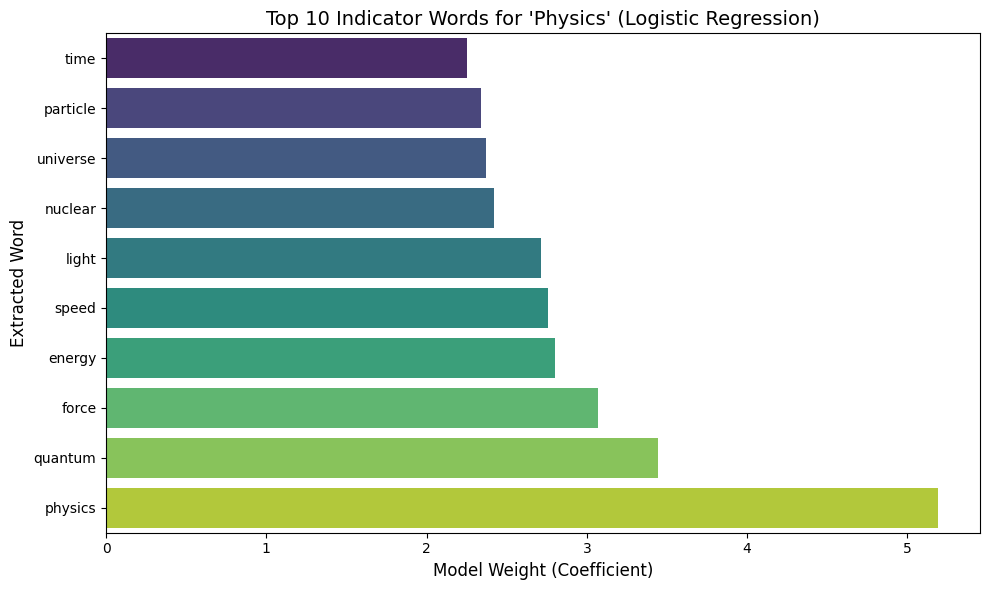

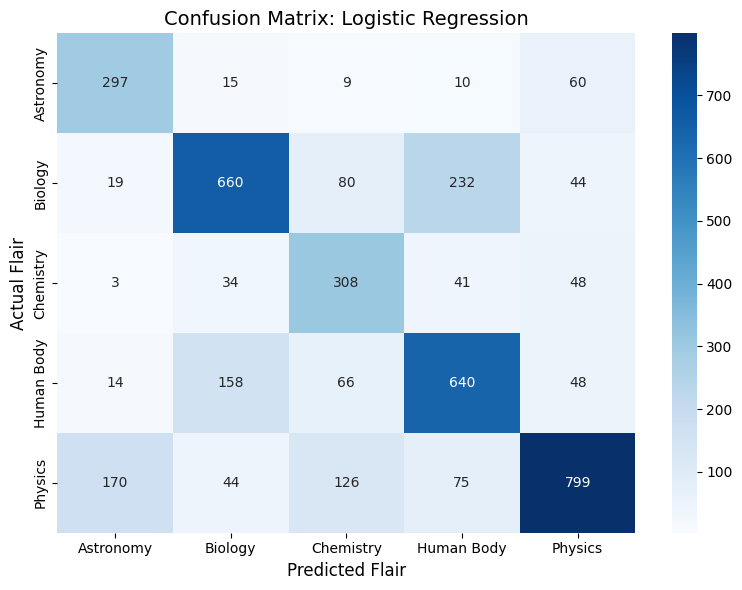

In [9]:
# --- CELL 5: GENERATING THE VISUAL EVIDENCE ---
import seaborn as sns
from sklearn.metrics import confusion_matrix

print("Generating visual evidence ")

# 1. Feature Importance Bar Chart (For 'Physics')
physics_idx = list(target_names).index('Physics')
top10_indices = np.argsort(coefs[physics_idx])[-10:]
top_words = [feature_names[j] for j in top10_indices]
top_weights = coefs[physics_idx][top10_indices]

plt.figure(figsize=(10, 6))
sns.barplot(x=top_weights, y=top_words, palette='viridis')
plt.title("Top 10 Indicator Words for 'Physics' (Logistic Regression)", fontsize=14)
plt.xlabel("Model Weight (Coefficient)", fontsize=12)
plt.ylabel("Extracted Word", fontsize=12)
plt.tight_layout()
plt.show()

# 2. The Confusion Matrix Heatmap
cm = confusion_matrix(y_test, log_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=target_names, yticklabels=target_names)
plt.title("Confusion Matrix: Logistic Regression", fontsize=14)
plt.xlabel("Predicted Flair", fontsize=12)
plt.ylabel("Actual Flair", fontsize=12)
plt.tight_layout()
plt.show()